# Decoding Music: Predicting Song Popularity and Discovering Mood Clusters
Run the cells from top to bottom. Wait for each cell to finish before running the next one.

## Step 1: Load data, clean, split, scale, train 5 models

In [1]:
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

sns.set_style("whitegrid")

found = glob.glob("/kaggle/input/**/dataset.csv", recursive=True)
path = found[0] if found else "dataset.csv"
df = pd.read_csv(path)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna()
df = df.drop_duplicates(subset="track_id").reset_index(drop=True)

features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
            "valence", "tempo", "duration_ms"]
df["is_hit"] = (df["popularity"] >= 50).astype(int)

X = df[features]
y = df["is_hit"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Songs:", df.shape[0], "| Train:", X_train.shape[0], "| Test:", X_test.shape[0])

sw = compute_sample_weight("balanced", y_train)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}
_ = [m.fit(X_train_scaled, y_train) for n, m in models.items() if n != "Gradient Boosting"]
_ = models["Gradient Boosting"].fit(X_train_scaled, y_train, sample_weight=sw)
preds = {n: m.predict(X_test_scaled) for n, m in models.items()}
probs = {n: m.predict_proba(X_test_scaled)[:, 1] for n, m in models.items()}
results_df = pd.DataFrame([{
    "Model": n,
    "Accuracy": accuracy_score(y_test, preds[n]),
    "Precision": precision_score(y_test, preds[n], zero_division=0),
    "Recall": recall_score(y_test, preds[n]),
    "F1": f1_score(y_test, preds[n]),
    "ROC-AUC": roc_auc_score(y_test, probs[n]),
} for n in models]).round(3).sort_values("F1", ascending=False)
print(results_df.to_string())

Songs: 89740 | Train: 71792 | Test: 17948
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
4    Gradient Boosting     0.595      0.332   0.705  0.452    0.682
1        Decision Tree     0.544      0.306   0.732  0.431    0.646
0  Logistic Regression     0.567      0.301   0.628  0.407    0.627
2        Random Forest     0.755      0.474   0.313  0.377    0.720
3                  KNN     0.756      0.448   0.140  0.214    0.667


## Step 2: Model comparison bar graph

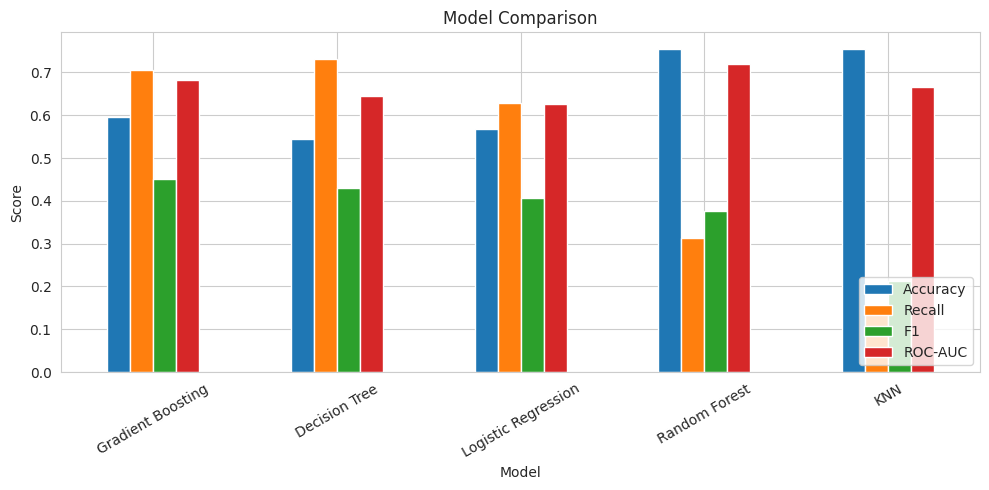

In [2]:
results_df.set_index("Model")[["Accuracy", "Recall", "F1", "ROC-AUC"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Step 3: Tune Random Forest (about 1 to 3 minutes)

In [3]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [3, 5, 10],
}
idx = np.random.RandomState(42).choice(len(X_train_scaled), 20000, replace=False)

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions=param_grid, n_iter=5, scoring="roc_auc", cv=3, random_state=42,
)
search.fit(X_train_scaled[idx], y_train.iloc[idx])
print("Best settings:", search.best_params_)
print("Best cross-validated ROC-AUC:", round(search.best_score_, 3))

tuned = RandomForestClassifier(**search.best_params_, class_weight="balanced", random_state=42, n_jobs=-1)
tuned.fit(X_train_scaled, y_train)
prob = tuned.predict_proba(X_test_scaled)[:, 1]
pred = tuned.predict(X_test_scaled)
print("Tuned test ROC-AUC:", round(roc_auc_score(y_test, prob), 3))
print("Tuned test Recall :", round(recall_score(y_test, pred), 3))
print("Tuned test F1     :", round(f1_score(y_test, pred), 3))

Best settings: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 12}
Best cross-validated ROC-AUC: 0.673
Tuned test ROC-AUC: 0.696
Tuned test Recall : 0.664
Tuned test F1     : 0.454


## Step 4: Confusion matrix and ROC curve

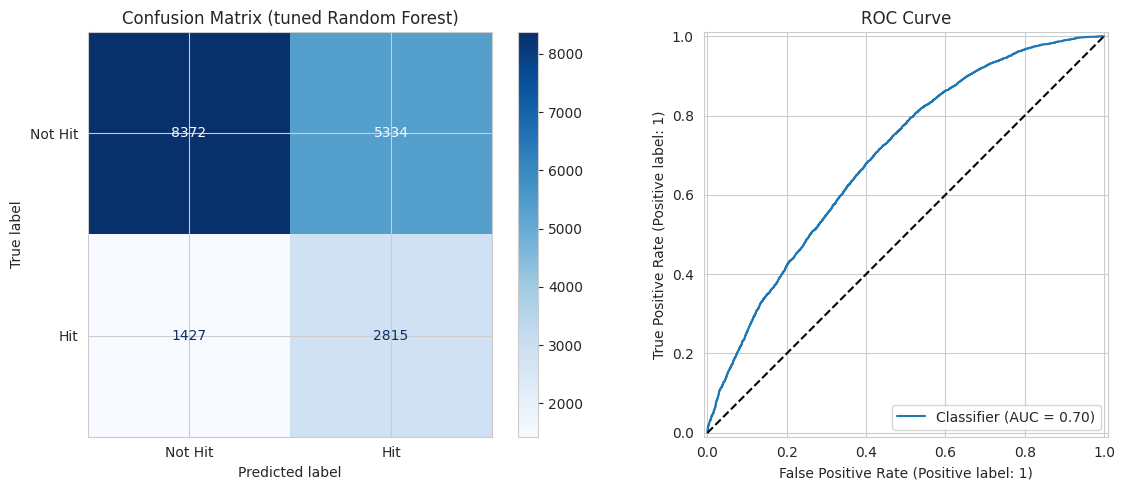

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Not Hit", "Hit"], ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix (tuned Random Forest)")
RocCurveDisplay.from_predictions(y_test, prob, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()

## Step 5: Which features matter most?

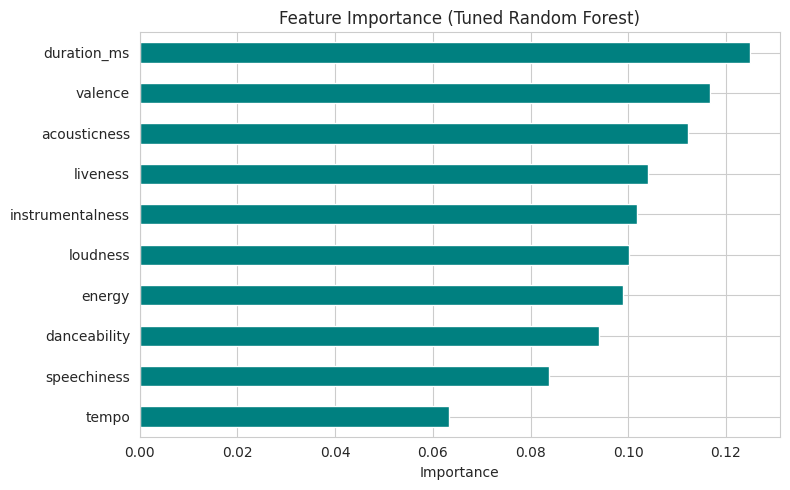

In [5]:
importances = pd.Series(tuned.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", figsize=(8, 5), color="teal")
plt.title("Feature Importance (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()